# 04 - Fine-tuning VGG-16 modela
U ovom notebook-u vrši se fine-tuning prethodno istreniranog VGG-16 transfer learning modela. Polazna tačka je model iz notebook-a 03_transfer_learning.ipynb, kod kojeg je konvoluciona baza VGG-16 bila potpuno zamrznuta. U ovoj fazi biće odmrznut deo gornjih konvolucionih slojeva kako bi se njihove težine dodatno prilagodile problemu klasifikacije pasa i mačaka. Fine-tuning će se vršiti sa manjom stopom učenja kako bi se izbegle velike promene prethodno ImageNet težina. Za evaluaciju se koristi isti train/validation/test split kao u prethodnim fazama.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive

print("TensorFlow verzija:", tf.__version__)

TensorFlow verzija: 2.20.0


In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Reproduktivnost
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Seed postavljen na {SEED}.")

Seed postavljen na 42.


In [ ]:
# Ucitavanje transfer learning modela
MODEL_DIR = "/content/drive/MyDrive/MU-projekat/models"
TRANSFER_MODEL_PATH = os.path.join(MODEL_DIR, "vgg16_transfer_learning.keras")
if not os.path.exists(TRANSFER_MODEL_PATH):
  raise FileNotFoundError(f"Transfer learning model nije pronadjen: {TRANSFER_MODEL_PATH}")

model = tf.keras.models.load_model(TRANSFER_MODEL_PATH)
print("Transfer learning model je uspesno ucitan.")

Transfer learning model je uspesno ucitan.


In [ ]:
model.summary()

Model: "vgg16_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,109,445 (57.64 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 263,172 (1.00 MB)

In [ ]:
# Pronalazenje vgg-16 baze u ucitanom modelu
base_model = model.get_layer("vgg16")

print("Naziv baze:", base_model.name)
print("Broj slojeva u VGG-16 bazi:", len(base_model.layers))
print("Da li je baza trenutno trainable:", base_model.trainable)

Naziv baze: vgg16
Broj slojeva u VGG-16 bazi: 19
Da li je baza trenutno trainable: False


In [ ]:
# Pregled poslednjih slojeva vgg-16 baze
for layer in base_model.layers[-10:]:
  print(f"{layer.name:20} | trainable = {layer.trainable}")

block3_conv3         | trainable = False
block3_pool          | trainable = False
block4_conv1         | trainable = False
block4_conv2         | trainable = False
block4_conv3         | trainable = False
block4_pool          | trainable = False
block5_conv1         | trainable = False
block5_conv2         | trainable = False
block5_conv3         | trainable = False
block5_pool          | trainable = False


In [ ]:
# Odmrzavanje poslednjeg vgg16 bloka
base_model.trainable = True

for layer in base_model.layers:
  if layer.name.startswith("block5"):
    layer.trainable = True
  else:
    layer.trainable = False

## Izbor slojeva za fine-tuning
Za fine-tuning je odmrznut samo poslednji konvolucioni blok VGG-16 mreze (block5). Nizi slojevi VGG-16 modela uglavnom izdvajaju opste vizuelne karakteristike, poput ivica, tekstura i jednostavnih oblika, koje su korisne i za novi problem klasifikacije. Visi slojevi predstavljaju specificnije karakteristike slika, pa njihovo dodatno treniranje omogucava prilagodjavanje modela razlikovanju pasa i macaka. Zbog toga su nizi blokovi ostavljeni zamrznuti, dok je poslednji blok dodatno treniran sa malom stopom ucenja (1e-5).

In [ ]:
# Provera trainable status slojeva
for layer in base_model.layers:
  print(f"{layer.name:20s} | trainable = {layer.trainable}")
print("Broj trainable slojeva u VGG-16 bazi:", sum(layer.trainable for layer in base_model.layers))

input_layer          | trainable = False
block1_conv1         | trainable = False
block1_conv2         | trainable = False
block1_pool          | trainable = False
block2_conv1         | trainable = False
block2_conv2         | trainable = False
block2_pool          | trainable = False
block3_conv1         | trainable = False
block3_conv2         | trainable = False
block3_conv3         | trainable = False
block3_pool          | trainable = False
block4_conv1         | trainable = False
block4_conv2         | trainable = False
block4_conv3         | trainable = False
block4_pool          | trainable = False
block5_conv1         | trainable = True
block5_conv2         | trainable = True
block5_conv3         | trainable = True
block5_pool          | trainable = True
Broj trainable slojeva u VGG-16 bazi: 4


In [ ]:
# Ponovo kompajliranje modela za fine-tuning
FINE_TUNE_LR = 1e-5

model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR), loss=tf.keras.losses.BinaryCrossentropy(), metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")])

print("Model je uspesno kompajliran za fine-tuning.")
print("Fine-tuning learning rate:", FINE_TUNE_LR)

Model je uspesno kompajliran za fine-tuning.
Fine-tuning learning rate: 1e-05


In [ ]:
# Provera broja treinabilnih i zamrznutih parametara

trainable_params = np.sum([np.prod(variable.shape) for variable in model.trainable_weights])
non_trainable_params = np.sum([np.prod(variable.shape) for variable in model.non_trainable_weights])

print("Trainable parametri:", trainable_params)
print("Non-trainable parametri:", non_trainable_params)

Trainable parametri: 7211009
Non-trainable parametri: 7635264


In [ ]:
# Ucitavanje split.csv
PROJECT_DIR = "/content/Household-Animals-Classification"
SPLIT_PATH = os.path.join(PROJECT_DIR, "split.csv")
split_df = pd.read_csv(SPLIT_PATH)
print("Dimenzija split tabele:", split_df.shape)
split_df.head()

Dimenzija split tabele: (25000, 3)


,filename,label,split
0,cat.5004.jpg,cat,train
1,dog.9777.jpg,dog,train
2,dog.2406.jpg,dog,train
3,dog.11980.jpg,dog,train
4,cat.10071.jpg,cat,train


In [ ]:
# Provera GPU okruzenja
gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
  print("GPU je dostupan.")
  print("GPU uredjaji:", gpu_devices)
else:
  print("GPU nije dostupan. Proveriti Colab Runtime podesavanja.")

GPU je dostupan.
GPU uredjaji: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
EXTRACT_DIR = "/content/drive/MyDrive/MU-projekat/data/dogs-vs-cats"
TRAIN_DIR = os.path.join(EXTRACT_DIR, "train")
DATASET_DIR = os.path.join(TRAIN_DIR, "train")
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(
        f"Dataset nije pronađen na putanji: {DATASET_DIR}"
    )

print("Dataset pronađen:", DATASET_DIR)

Dataset pronađen: /content/drive/MyDrive/MU-projekat/data/dogs-vs-cats/train/train


In [ ]:
# Kreiranje train, validation i test skupova prema split-u
train_df = split_df[split_df["split"] == "train"].copy()
val_df = split_df[split_df["split"] == "val"].copy()
test_df = split_df[split_df["split"] == "test"].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (20000, 3)
Validation: (4000, 3)
Test: (1000, 3)


In [ ]:
# Putanje do slika i numericke labele
CLASS_NAMES = ["cat", "dog"]

label_to_index = {"cat": 0, "dog": 1}

for df in [train_df, val_df, test_df]:
    df["filepath"] = df["filename"].apply(lambda filename: os.path.join(DATASET_DIR, filename))
    df["label_index"] = df["label"].map(label_to_index)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (20000, 5)
Validation: (4000, 5)
Test: (1000, 5)


,filename,label,split,filepath,label_index
0,cat.5004.jpg,cat,train,/content/drive/MyDrive/MU-projekat/data/dogs-v...,0
1,dog.9777.jpg,dog,train,/content/drive/MyDrive/MU-projekat/data/dogs-v...,1
2,dog.2406.jpg,dog,train,/content/drive/MyDrive/MU-projekat/data/dogs-v...,1
3,dog.11980.jpg,dog,train,/content/drive/MyDrive/MU-projekat/data/dogs-v...,1
4,cat.10071.jpg,cat,train,/content/drive/MyDrive/MU-projekat/data/dogs-v...,0


In [ ]:
# Parametri za ucitavanje
IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
# Ucitavanje i priprema slike
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)

    label = tf.cast(label, tf.float32)

    return image, label

In [ ]:
# Kreiranje tensorflow dataset-a
def create_dataset(df, training=False):
    filepaths = df["filepath"].values
    labels = df["label_index"].values

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if training:
        dataset = dataset.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
train_dataset = create_dataset(train_df, training=True)

val_dataset = create_dataset(val_df, training=False)

test_dataset = create_dataset(test_df, training=False)

print("TensorFlow dataset-i su uspešno kreirani.")

TensorFlow dataset-i su uspešno kreirani.


In [ ]:
# Callback funkcije za fine-tuning
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1)

In [ ]:
# fine-tuning
FINE_TUNE_EPOCHS = 10
history_fine = model.fit(train_dataset, validation_data=val_dataset, epochs=FINE_TUNE_EPOCHS, callbacks=[early_stopping, reduce_lr])


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 185ms/step - accuracy: 0.9855 - loss: 0.0418 - val_accuracy: 0.9883 - val_loss: 0.0291 - learning_rate: 1.0000e-05
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 201ms/step - accuracy: 0.9897 - loss: 0.0297 - val_accuracy: 0.9898 - val_loss: 0.0267 - learning_rate: 1.0000e-05
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 124s 198ms/step - accuracy: 0.9934 - loss: 0.0203 - val_accuracy: 0.9875 - val_loss: 0.0362 - learning_rate: 1.0000e-05
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9943 - loss: 0.0183
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 211ms/step - accuracy: 0.9937 - loss: 0.0184 - val_accuracy: 0.9877 - val_loss: 0.0383 - learning_rate: 1.0000e-05
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 207ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 0.9912 - val_loss: 0.0299 - learning_rate: 5.0000e-06
Epoch 5: early stopping
Restoring model weights

In [ ]:
# Priprema podataka za vizualizaciju treninga
train_accuracy = history_fine.history["accuracy"]
val_accuracy = history_fine.history["val_accuracy"]

train_loss = history_fine.history["loss"]
val_loss = history_fine.history["val_loss"]

epochs_range = range(1, len(train_accuracy) + 1)

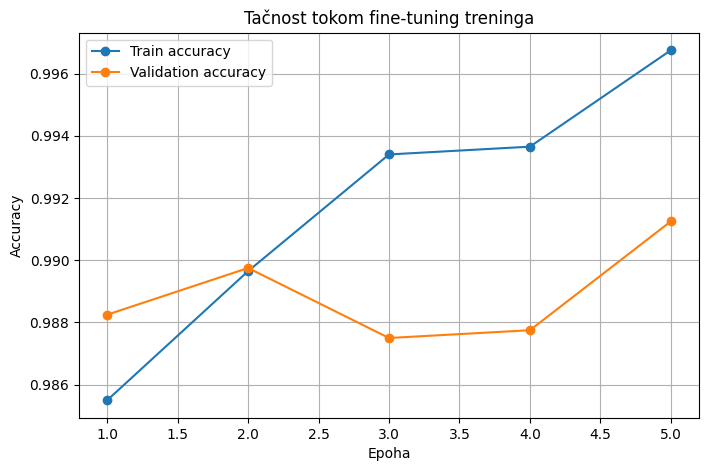

In [ ]:
# Grafikon tacnosti kroz epohe
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, train_accuracy, marker="o", label="Train accuracy")

plt.plot(epochs_range, val_accuracy, marker="o", label="Validation accuracy")

plt.xlabel("Epoha")
plt.ylabel("Accuracy")
plt.title("Tačnost tokom fine-tuning treninga")
plt.legend()
plt.grid()

plt.show()

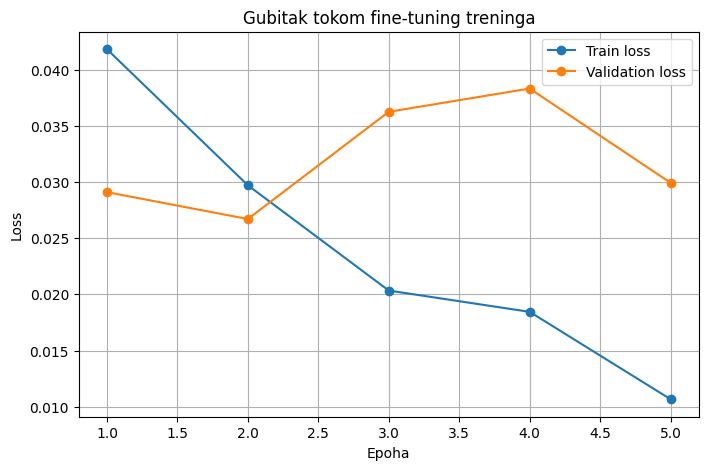

In [ ]:
# Grafikon gubitka kroz epohe
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, train_loss, marker="o", label="Train loss")

plt.plot(epochs_range, val_loss, marker="o", label="Validation loss")

plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.title("Gubitak tokom fine-tuning treninga")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# Evaluacija fine-tuned modela na test skupu
test_loss_fine, test_accuracy_fine = model.evaluate(test_dataset, verbose=1)

print(f"Test loss: {test_loss_fine:.4f}")
print(f"Test accuracy: {test_accuracy_fine:.4f}")
print(f"Test accuracy (%): {test_accuracy_fine * 100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.9900 - loss: 0.0305
Test loss: 0.0305
Test accuracy: 0.9900
Test accuracy (%): 99.00%


In [ ]:
# Predikcija na test skupu
y_prob_fine = model.predict(test_dataset, verbose=1).ravel()

y_pred_fine = (y_prob_fine >= 0.5).astype(int)

y_true = test_df["label_index"].to_numpy()

print("Broj predikcija:", len(y_pred_fine))
print("Broj stvarnih labela:", len(y_true))

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step
Broj predikcija: 1000
Broj stvarnih labela: 1000


In [ ]:
# Metrike na test skupu
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report)

accuracy_fine = accuracy_score(y_true, y_pred_fine)

precision_fine = precision_score(y_true, y_pred_fine)

recall_fine = recall_score(y_true, y_pred_fine)

f1_fine = f1_score(y_true, y_pred_fine)

print(f"Accuracy:  {accuracy_fine:.4f}")
print(f"Precision: {precision_fine:.4f}")
print(f"Recall:    {recall_fine:.4f}")
print(f"F1-score:  {f1_fine:.4f}")
print(classification_report(y_true, y_pred_fine, target_names=CLASS_NAMES, digits=4))

Accuracy:  0.9900
Precision: 0.9900
Recall:    0.9900
F1-score:  0.9900
              precision    recall  f1-score   support

         cat     0.9900    0.9900    0.9900       500
         dog     0.9900    0.9900    0.9900       500

    accuracy                         0.9900      1000
   macro avg     0.9900    0.9900    0.9900      1000
weighted avg     0.9900    0.9900    0.9900      1000



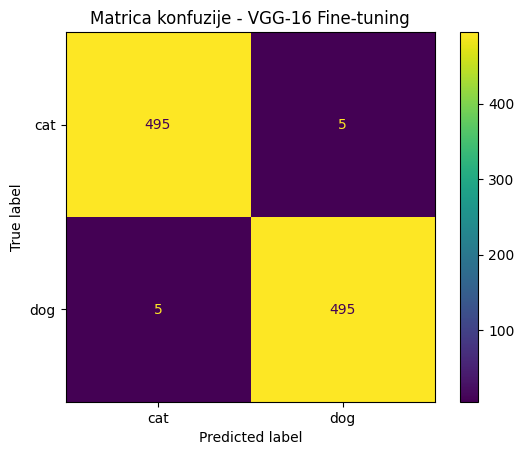

Matrica konfuzije:
[[495   5]
 [  5 495]]


In [ ]:
# Matrica konfuzije
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_fine = confusion_matrix(y_true, y_pred_fine)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_fine, display_labels=CLASS_NAMES)

disp.plot(values_format="d")
plt.title("Matrica konfuzije - VGG-16 Fine-tuning")
plt.show()
print("Matrica konfuzije:")
print(cm_fine)

In [ ]:
# Poredjenje transfer learning i fine-tuning modela
comparison_df = pd.DataFrame({"Model": ["VGG-16 Transfer Learning", "VGG-16 Fine-tuning"], "Accuracy": [0.9810, accuracy_fine], "Precision": [0.9839, precision_fine], "Recall": [0.9780, recall_fine], "F1-score": [0.9809, f1_fine]})

comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,VGG-16 Transfer Learning,0.981,0.9839,0.978,0.9809
1,VGG-16 Fine-tuning,0.990,0.9900,0.990,0.9900


## Zakljucak
Fine-tuning VGG-16 modela doveo je do poboljsanja preformansi u odnosu na prethodni transfer learning pristup sa porpuno zamrznutom konvolucionom bazom. Tokom fine-tuning faze odmrznut je poslednji konvolucioni blok VGG-16 modela (block5), dok su nizi blokovi ostali zamrznuti. Model je dodatno treniran sa manjom stopom ucenja (1e-5) kako bi se prethodno naucene ImageNet tezine postepeno prilagodile problemu klasifikacije pasa i macaka.
Najbolji validation loss ostvaren je u drugoj epohi. Nakon toga training accuracy je nastavila da raste, dok se validation loss pogorsavao, sto ukazuje na pocetak overfitting-a. Early stopping je zbog toga zaustavio trening i vratio tezine iz najbolje epohe.
Na test skupu fine-tuned model ostvario je:
- Accuracy: 99.00%
- Precision: 99.00%
- Recall: 99.00%
- F1-score: 99.00%

U odnosu na transfer learning model, cija je test tacnost bila 98.10%, fine-tuning je povecao tacnost za 0.90 procentnih poena.
Matrica konfuzije pokazuje veoma ujednacene rezultate za obe klase, sto ukazuje da model nema izrazenu pristrasnost ka jednoj od klasa.
Dobijeni rezultati pokazuju da je dodatno prilagodjavanje visih VGG-16 konvolucionih slojeva posmatranom domenu poboljsalo sposobnost modela da razlikuje pse i macke.

In [ ]:
# Cuvanje fine-tuned modela
FINETUNED_MODEL_PATH = os.path.join(MODEL_DIR, "vgg16_finetuned.keras")

model.save(FINETUNED_MODEL_PATH)

print("Fine-tuned model je sačuvan na:")
print(FINETUNED_MODEL_PATH)
print(
    "Model uspešno sačuvan:",
    os.path.exists(FINETUNED_MODEL_PATH)
)

Fine-tuned model je sačuvan na:
/content/drive/MyDrive/MU-projekat/models/vgg16_finetuned.keras
